# Day2 · 블록3 · 센서 데이터 시뮬레이션 실습

> **강의자료**: `강의자료/02.03.Python-Data-Simulation.md`

| Part | 주제 |
|------|------|
| Part 1 | 전체 구조 설계 |
| Part 2 | 단계별 코드 구현 |
| Part 3 | 오류 해결과 심화 미션 |
| Part 4 | Day3 연결 브리지 |

**실습 목표**:
OOP(객체 지향 프로그래밍)의 핵심 개념(추상화·상속·다형성)을 이해하고,
NumPy로 LiDAR·IMU 센서 데이터를 생성한 뒤 Matplotlib으로 시각화합니다.

---
## Part 1: 전체 구조 설계

로봇 시스템은 다양한 센서로 구성됩니다.
이 실습에서는 공통 인터페이스(추상 클래스)를 먼저 설계하고,
LiDAR·IMU 센서를 상속으로 구현합니다.

### 클래스 다이어그램 — 설계도 먼저 보기

```
[ Abstract Class: Sensor ]
        ▲
        │ (Inheritance)
        ├──────────────────────────┐
[ Subclass: LiDAR ]        [ Subclass: IMU ]
- scan_range: float        - axis: int (3)
- num_samples: int         - frequency: int
+ get_data()               + get_data()
(Returns 2D points)        (Returns Accel/Gyro)
```

- **추상 클래스(Abstract Class)**: 직접 사용 불가, 자식 클래스가 반드시 `get_data()`를 구현해야 함
- **하드웨어 추상화 계층(HAL)**: 센서 종류가 바뀌어도 상위 코드를 수정할 필요 없음

### 단계별 구현 순서 — 5 Steps

- **Step 1**: `abc` 모듈로 센서의 공통 인터페이스를 정의하는 **추상 클래스** 작성
- **Step 2**: LiDAR 센서 클래스를 상속받아 구현하고, **NumPy**로 거리 데이터 생성
- **Step 3**: IMU 센서 클래스를 상속받아 구현하고, **다차원 가속도 데이터** 생성
- **Step 4**: **다형성(Polymorphism)** 을 활용해 여러 센서 객체를 리스트로 관리하고 데이터 수집
- **Step 5**: **Matplotlib**을 사용하여 수집된 노이즈 데이터를 시각화

---
## Part 2: 단계별 코드 구현

### Step 1 — 추상 클래스 Sensor 정의

`abc` 모듈의 `ABC`와 `abstractmethod`를 사용하여
모든 센서의 설계도(인터페이스)를 정의합니다.

- **`@abstractmethod` 데코레이터**: 자식 클래스에서 반드시 구현해야 하는 메서드 선언
- **직접 인스턴스 생성 불가**: `Sensor("test")` → `TypeError` 발생

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
import json

# 센서 추상 클래스: 모든 센서의 설계도 역할
class Sensor(ABC):
    def __init__(self, name):
        self.name = name

        @abstractmethod
        def get_data(self):
            """센서로부터 데이터를 읽어오는 추상 메서드"""
            pass

# 추상 클래스는 직접 인스턴스화할 수 없음을 확인
try:
    s = Sensor("test")
except TypeError as e:
    print(f"추상 클래스 인스턴스화 오류: {e}")

### Step 2 — LiDAR 센서 클래스 구현

LiDAR는 로봇 주변의 거리를 360도 방향으로 측정합니다.
NumPy 벡터화 연산으로 전체 스캔 포인트를 한 번에 처리합니다.

- **`super().__init__(name)`**: 부모 클래스의 생성자를 호출하여 `self.name` 초기화
- **`np.linspace`**: 0부터 2π까지 균등 간격으로 360개의 값을 생성
- **`np.random.normal(0, 0.1, ...)`**: 평균 0, 표준편차 0.1의 가우시안 노이즈

In [6]:
# LiDAR 센서 클래스: 거리 데이터를 생성
class LidarSensor(Sensor):
    def __init__(self, name, n_sample = 360):
        super().__init__(name)
        self.n_sample = n_sample

    def get_data(self):
        angles = np.linspace(0, np.pi * 2, self.n_sample)
        distances = 5.0 + np.random.normal(0, 0.1, self.n_sample)
        return angles, distances

# LiDAR 센서 테스트
lidar = LidarSensor("Hokuyo_LiDAR")
angles, distances = lidar.get_data()
print(f"LiDAR 이름: {lidar.name}")
print(f"각도 배열 shape: {angles.shape}, 첫 값: {angles[0]:.4f}")
print(f"거리 배열 shape: {distances.shape}, 평균: {distances.mean():.4f}m")

LiDAR 이름: Hokuyo_LiDAR
각도 배열 shape: (360,), 첫 값: 0.0000
거리 배열 shape: (360,), 평균: 4.9991m


### Step 3 — IMU 센서 클래스 구현

IMU는 가속도와 각속도를 측정합니다.
고주파 데이터를 NumPy 2D 배열로 처리합니다.

- **`np.arange(self.duration)`**: 0부터 duration-1까지의 정수 배열 (시간 인덱스)
- **`np.random.randn(duration, 3)`**: shape이 (100, 3)인 2D 배열 — 행: 시간, 열: x/y/z 축
- **`* 0.5`**: 표준편차를 0.5로 스케일링

In [7]:
# IMU 센서 클래스: 3축 가속도 데이터 생성
class ImuSensor(Sensor):
    def __init__(self, name, duration=100):
        super().__init__(name)
        self.duration = duration
    def get_data(self):
        # 시간축 생성
        t = np.arange(self.duration)
        # 3축(x, y, z)에 대한 가속도 데이터 생성 (랜덤 노이즈 포함)        
        accel_data = np.random.randn(self.duration, 3) * 0.5        
        return t, accel_data

# IMU 센서 테스트
imu = ImuSensor("InvenSense_IMU")
t, accel = imu.get_data()
print(f"IMU 이름: {imu.name}")
print(f"시간 배열 shape: {t.shape}")
print(f"가속도 배열 shape: {accel.shape}  (행: 시간, 열: X/Y/Z 축)")
print(f"X축 가속도 표준편차: {accel[:, 0].std():.4f}")

IMU 이름: InvenSense_IMU
시간 배열 shape: (100,)
가속도 배열 shape: (100, 3)  (행: 시간, 열: X/Y/Z 축)
X축 가속도 표준편차: 0.4720


### Step 4 — 다형성으로 센서 통합 관리

서로 다른 센서 객체를 하나의 리스트로 관리하고
동일한 `get_data()` 호출로 데이터를 수집합니다.

- **다형성 핵심**: `sensor.get_data()` 한 줄로 LiDAR와 IMU 모두 처리
- **`plt.subplots(1, 2)`**: 1행 2열의 서브플롯 생성 → `ax1`(LiDAR), `ax2`(IMU)
- **`isinstance(sensor, LidarSensor)`**: 객체 타입을 확인하여 시각화 분기 처리

### Step 5 — Matplotlib으로 데이터 시각화

극좌표를 직교좌표로 변환하여 LiDAR 스캔을 2D로,
IMU는 시계열 그래프로 표시합니다.

- **`x = dists * np.cos(angles)`**: 극좌표 `(r, θ)` → 직교좌표 `x = r·cos(θ)`
- **`accel[:, 0]`**: 2D 배열에서 0번째 열(X축) 전체를 슬라이싱
- **`plt.tight_layout()`**: 서브플롯 간 여백을 자동으로 조정
- **로봇 소프트웨어에서의 의미**: 이 `for sensor in sensors:` 루프가 로봇의 **'Sense' 루틴**

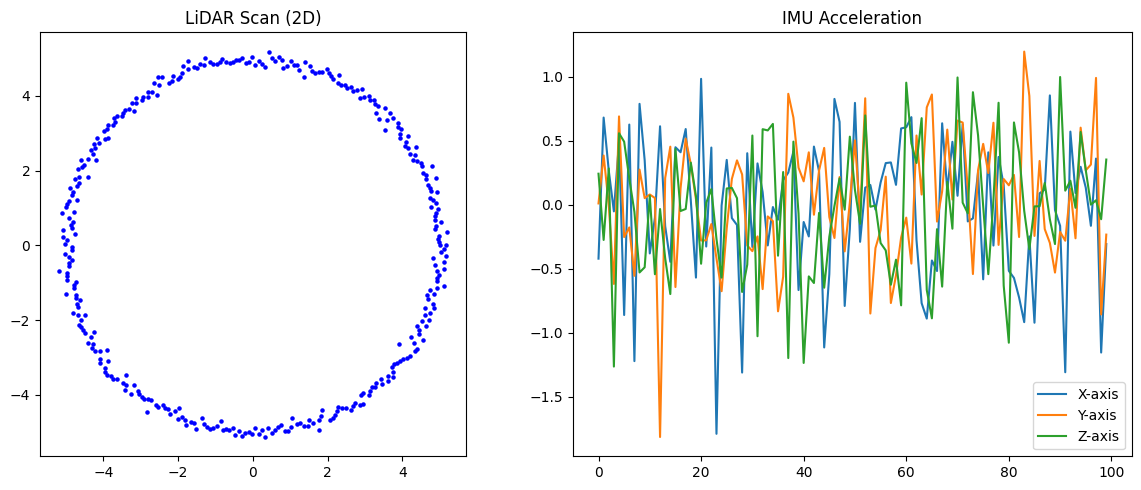

In [8]:
def main():
    # 센서 객체 생성 (다형성 활용)
    lidar = LidarSensor("Hokuyo_LiDAR")
    imu = ImuSensor("InvenSense_IMU")
    sensors = [lidar, imu]

    # 시각화 설정
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    for sensor in sensors:
        data = sensor.get_data()  # 타입에 관계없이 동일하게 호출
        
        if isinstance(sensor, LidarSensor):
            angles, dists = data
            x = dists * np.cos(angles)
            y = dists * np.sin(angles)
            ax1.scatter(x, y, s=5, c='blue', label=sensor.name)
            ax1.set_title("LiDAR Scan (2D)")
            ax1.set_aspect('equal')

        elif isinstance(sensor, ImuSensor):
            time, accel = data
            ax2.plot(time, accel[:, 0], label='X-axis')
            ax2.plot(time, accel[:, 1], label='Y-axis')
            ax2.plot(time, accel[:, 2], label='Z-axis')
            ax2.set_title("IMU Acceleration")
            ax2.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

---
## Part 3: 오류 해결과 심화 미션

### 자주 발생하는 오류와 해결법

| 단계 | 발생 가능 오류 | 원인 및 해결법 |
| :--- | :--- | :--- |
| **OOP** | `TypeError: Can't instantiate abstract class...` | 추상 메서드 `get_data`를 자식 클래스에서 구현하지 않은 경우. 메서드 이름을 확인하고 반드시 재정의해야 함 |
| **NumPy** | `ValueError: operands could not be broadcast...` | 배열 간 연산 시 크기가 맞지 않은 경우. `np.shape()`로 데이터 차원 확인 필요 |
| **Matplotlib** | 그래프 창이 뜨지 않거나 바로 닫힘 | `plt.show()` 누락 또는 IDE 환경 설정 문제. 환경을 재점검해야 함 |
| **Common** | `IndentationError` | 파이썬은 들여쓰기가 문법의 핵심. 탭(Tab) 대신 4칸 공백(Space)을 일관되게 사용해야 함 |

### 심화 미션 1 — 이동 평균 필터 구현

NumPy를 활용하여 IMU 데이터의 노이즈를 줄이는 이동 평균 필터를 작성합니다.
필터링 전후 데이터를 비교 시각화합니다.

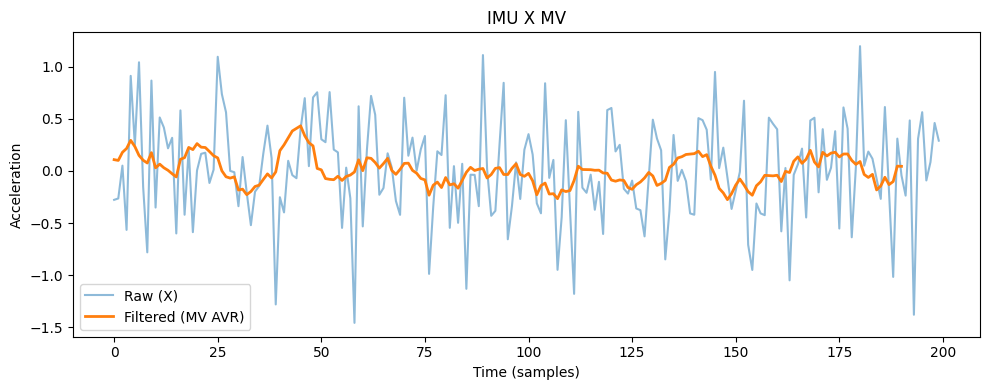

In [12]:
def moving_average(data, window_size=5):
    """이동 평균 필터: np.convolve를 활용하여 노이즈 제거"""
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='valid')

# IMU 데이터 생성 후 X축 필터링 비교 시각화
imu_demo = ImuSensor("InvenSense_IMU", duration=200)
t, accel = imu_demo.get_data()
filtered = moving_average(accel[:, 0], window_size=10)

plt.figure(figsize=(10, 4))
plt.plot(t, accel[:, 0], label='Raw (X)', alpha=0.5)
plt.plot(t[:len(filtered)], filtered, label='Filtered (MV AVR)', linewidth=2)
plt.title("IMU X MV")
plt.xlabel("Time (samples)")
plt.ylabel("Acceleration")
plt.legend()
plt.tight_layout()
plt.show()

### 심화 미션 2 — JSON으로 데이터 저장

수집된 센서 데이터를 `json` 모듈로 파일에 저장하고 다시 불러와 시각화합니다.

- **왜 JSON인가?**: 사람이 읽기 쉽고 파이썬 딕셔너리와 구조가 유사
  → 로봇 설정값·로그 저장의 표준적인 방식

In [13]:
# 데이터 저장
imu_save = ImuSensor("InvenSense_IMU")
t, accel = imu_save.get_data()

log = {
    "sensor": imu_save.name,
    "time": t.tolist(),
    "accel": accel.tolist()
}

with open("sensor_log.json", "w") as f:
    json.dump(log, f, indent=2)

print("sensor_log.json 저장 완료")

# 데이터 불러오기
with open("sensor_log.json", "r") as f:
    loaded = json.load(f)

print(f"로드된 센서 이름: {loaded['sensor']}")
print(f"데이터 길이(시간): {len(loaded['time'])}")
print(f"가속도 배열 shape: {len(loaded['accel'])} x {len(loaded['accel'][0])}")

sensor_log.json 저장 완료
로드된 센서 이름: InvenSense_IMU
데이터 길이(시간): 100
가속도 배열 shape: 100 x 3


### 심화 미션 3 — 동적(실시간) 시각화

`while` 루프와 `plt.pause()`를 사용하여 센서 데이터가 실시간으로
업데이트되는 시뮬레이션을 구현합니다.

- **`plt.ion()`**: Matplotlib 인터랙티브 모드 — `plt.show()` 없이도 즉시 화면 갱신
- **`plt.pause(0.1)`**: 0.1초 대기하는 동안 화면을 업데이트하는 핵심 함수

> **주의**: 아래 셀은 무한 루프입니다. 실행 후 중단하려면 커널을 인터럽트(Ctrl+C)하세요.

In [ ]:
# 실시간 LiDAR 스캔 시뮬레이션 (10회 반복)
lidar_rt = LidarSensor("Hokuyo_LiDAR")

plt.ion()  # 인터랙티브 모드 활성화
fig_rt, ax_rt = plt.subplots(figsize=(6, 6))

for frame in range(10):  # 무한 루프 대신 10 프레임만 반복
    ax_rt.clear()
    angles, dists = lidar_rt.get_data()
    x = dists * np.cos(angles)
    y = dists * np.sin(angles)
    ax_rt.scatter(x, y, s=5, c='blue')
    ax_rt.set_title(f"LiDAR Real-time Scan (frame {frame + 1}/10)")
    ax_rt.set_aspect('equal')
    ax_rt.set_xlim(-7, 7)
    ax_rt.set_ylim(-7, 7)
    plt.pause(0.1)  # 100ms 대기 후 업데이트

plt.ioff()  # 인터랙티브 모드 해제
plt.show()

### 실습 요약

- **OOP**: 추상 클래스 `Sensor` → `LidarSensor` · `ImuSensor` 상속 구현
- **NumPy**: 벡터화 연산으로 360개 LiDAR 포인트, 3축 IMU 데이터를 한 번에 생성
- **Matplotlib**: 극좌표 변환으로 2D 스캔 시각화, 시계열 가속도 그래프 표시
- **다형성**: 서로 다른 센서를 하나의 루프에서 통합 처리

### TODO 실습 — 나만의 센서 클래스 만들기

아래 뼈대 코드를 완성하여 **초음파(Ultrasonic) 센서** 클래스를 구현하세요.

**요구사항**:
- `Sensor`를 상속하고 `get_data()`를 구현
- `get_data()`는 `(distances,)` 형태의 NumPy 배열을 반환
- 거리 범위: 0.02m ~ 4.0m (초음파 센서 특성)
- 가우시안 노이즈 추가 (표준편차 0.05)
- 생성 후 히스토그램으로 거리 분포 시각화

/home/gs/Workspace/Robot_project/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gs/Workspace/Robot_project/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gs/Workspace/Robot_project/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gs/Workspace/Robot_project/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gs/Workspace/Robot_project/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py

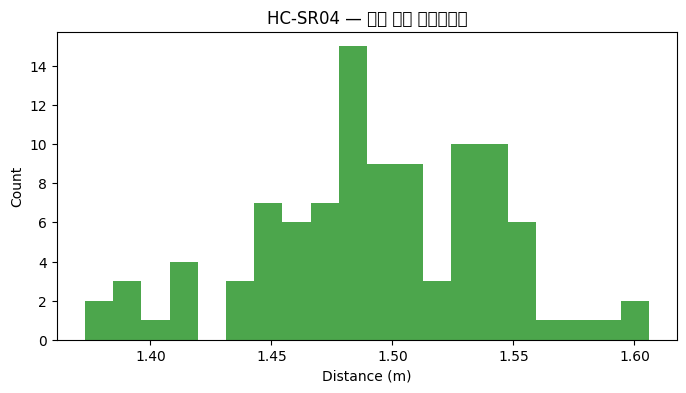

In [17]:
class UltrasonicSensor(Sensor):
    def __init__(self, name, num_samples=50, base_distance=1.0):
        super().__init__(name)
        self.num_samples = num_samples
        self.base_distance = base_distance

    def get_data(self):
        # TODO: 여기에 구현하세요
        distances = np.random.normal(self.base_distance, 0.05, self.num_samples)
        return distances

# 완성 후 주석 해제하여 테스트
ultrasonic = UltrasonicSensor("HC-SR04", num_samples=100, base_distance=1.5)
distances = ultrasonic.get_data()
plt.figure(figsize=(8, 4))
plt.hist(distances, bins=20, color='green', alpha=0.7)
plt.title(f"{ultrasonic.name} — 거리 분포 히스토그램")
plt.xlabel("Distance (m)")
plt.ylabel("Count")
plt.show()